In [8]:
import torch
import matplotlib.pyplot as plt

from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

In [9]:
class MVTecDataset(Dataset):
    def __init__(self, root, category, split, transform=None):
        self.transform = transform
        self.img_paths = []
        self.labels = []

        root = Path(root)

        if split == "train":
            good_dir = root / category / "train" / "good"
            for img_path in sorted(good_dir.glob("*.png")):
                self.img_paths.append(img_path)
                self.labels.append(0)
        
        elif split == "test":
            test_dir = root / category / "test"
            for sub_dir in sorted(test_dir.iterdir()):
                label = 0 if sub_dir.name == "good" else 1
                for img_path in sorted(sub_dir.glob("*.png")):
                    self.img_paths.append(img_path)
                    self.labels.append(label)

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)

        return img, self.labels[idx]


In [10]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def show_batch(imgs, labels, n=5):
    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    for i in range(n):
        img = imgs[i] * std + mean
        img = img.permute(1, 2, 0).numpy()
        img = img.clip(0, 1)
        axes[i].imshow(img)
        axes[i].set_title(f"label={labels[i].item()}")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

In [11]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],     
        std=[0.229, 0.224, 0.225]
    )
])

Train images: 209
torch.Size([32, 3, 224, 224]) tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])


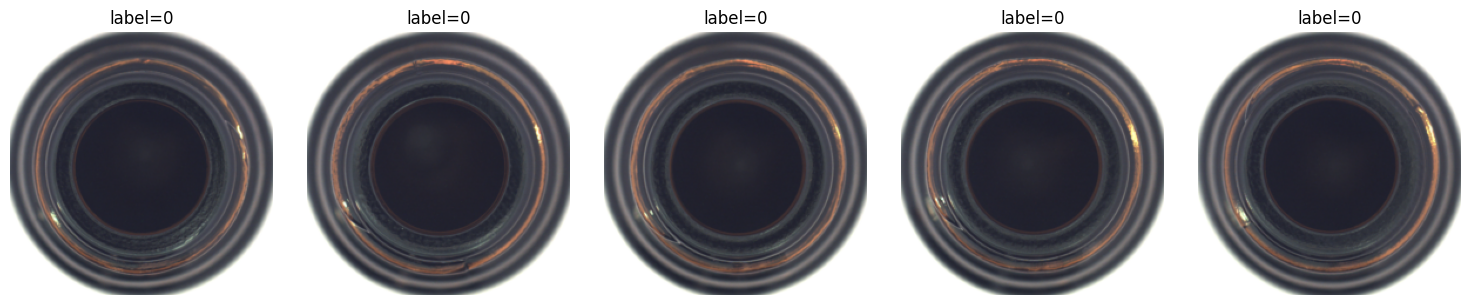

In [14]:
train_data = MVTecDataset(
    root = "data/mvtec_anomaly_detection",
    category="bottle",
    split = "train",
    transform=transform
) 

train_loader = DataLoader(
    dataset = train_data,
    batch_size = 32,
    shuffle = True,
    num_workers = 0
)

imgs, labels = next(iter(train_loader))
print(f"Train images: {len(train_data)}")

print(imgs.shape, labels)

show_batch(imgs, labels)